In [44]:
# Import Libraries

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    validation_curve
)

from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss
)

from sklearn.calibration import CalibrationDisplay

In [45]:
# Load Dataset

df = pd.read_csv(
    "/content/drive/MyDrive/Heart Disease Cleveland UCI/heart_cleveland_upload.csv"
)

In [46]:
# Dataset Overview

display(df.head())

print("Shape:", df.shape)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Shape: (297, 14)


In [47]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [48]:
# Features and Target

X = df.drop("condition", axis=1)

y = df["condition"]

In [49]:
# Missing Values

print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [50]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [51]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [52]:
# Model Initialization

gnb = GaussianNB()
# Model Training

start_train = time.time()

gnb.fit(X_train, y_train)

train_time = time.time() - start_train

print(f"Training Time : {train_time:.4f} seconds")

Training Time : 0.0025 seconds


In [53]:
# Prediction

start_test = time.time()

y_pred = gnb.predict(X_test)

y_prob = gnb.predict_proba(X_test)[:, 1]

test_time = time.time() - start_test

print(f"Prediction Time : {test_time:.4f} seconds")

Prediction Time : 0.0021 seconds


In [54]:
# Performance Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

mcc = matthews_corrcoef(y_test, y_pred)

kappa = cohen_kappa_score(y_test, y_pred)

loss = log_loss(y_test, y_prob)

cv_scores = cross_val_score(
    gnb,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

cv_mean = cv_scores.mean()

cv_std = cv_scores.std()

In [55]:
# Print Performance Metrics

print("Gaussian Naive Bayes Performance\n")

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")
print(f"Matthews CC         : {mcc:.4f}")
print(f"Cohen's Kappa       : {kappa:.4f}")
print(f"Log Loss            : {loss:.4f}")

print(f"\nCV Mean Accuracy    : {cv_mean:.4f}")
print(f"CV Std              : {cv_std:.4f}")

print(f"\nTraining Time       : {train_time:.4f} sec")
print(f"Prediction Time     : {test_time:.4f} sec")

Gaussian Naive Bayes Performance

Accuracy            : 0.8667
Precision           : 1.0000
Recall              : 0.7143
F1 Score            : 0.8333
ROC-AUC             : 0.9129
Balanced Accuracy   : 0.8571
Matthews CC         : 0.7559
Cohen's Kappa       : 0.7273
Log Loss            : 0.4326

CV Mean Accuracy    : 0.8275
CV Std              : 0.0531

Training Time       : 0.0025 sec
Prediction Time     : 0.0021 sec


In [56]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89        32
           1       1.00      0.71      0.83        28

    accuracy                           0.87        60
   macro avg       0.90      0.86      0.86        60
weighted avg       0.89      0.87      0.86        60



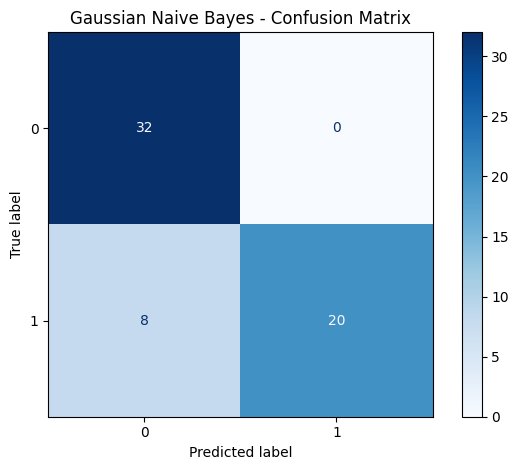

In [57]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")

plt.tight_layout()

plt.show()

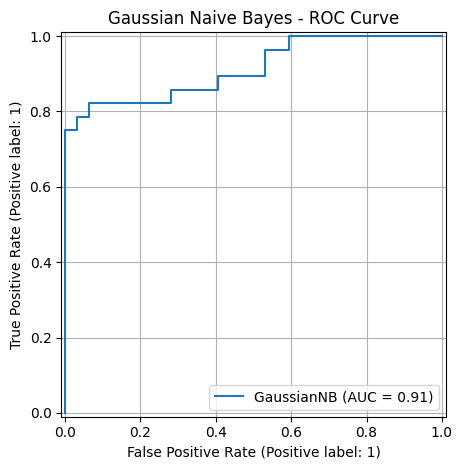

In [58]:
# ROC Curve

RocCurveDisplay.from_estimator(
    gnb,
    X_test,
    y_test
)

plt.title("Gaussian Naive Bayes - ROC Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

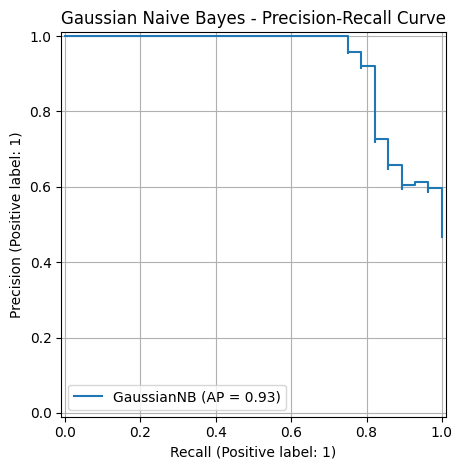

In [59]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(
    gnb,
    X_test,
    y_test
)

plt.title("Gaussian Naive Bayes - Precision-Recall Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

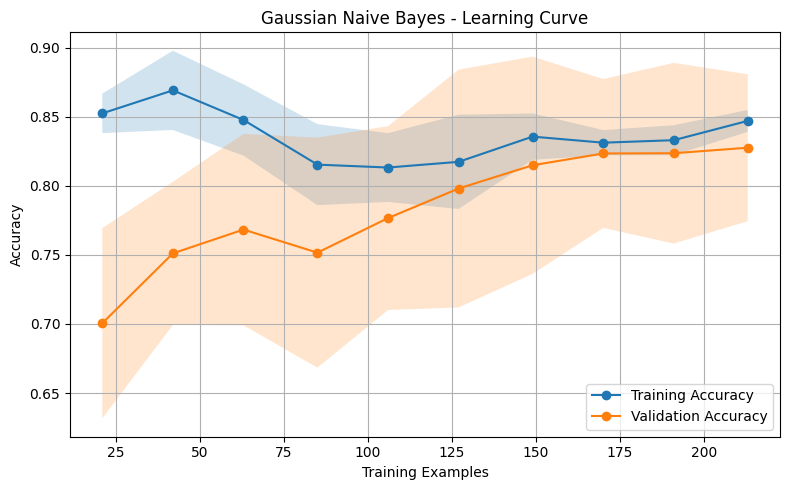

In [60]:
# Learning Curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=gnb,
    X=X_train,
    y=y_train,
    cv=10,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    test_mean-test_std,
    test_mean+test_std,
    alpha=0.2
)

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Gaussian Naive Bayes - Learning Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

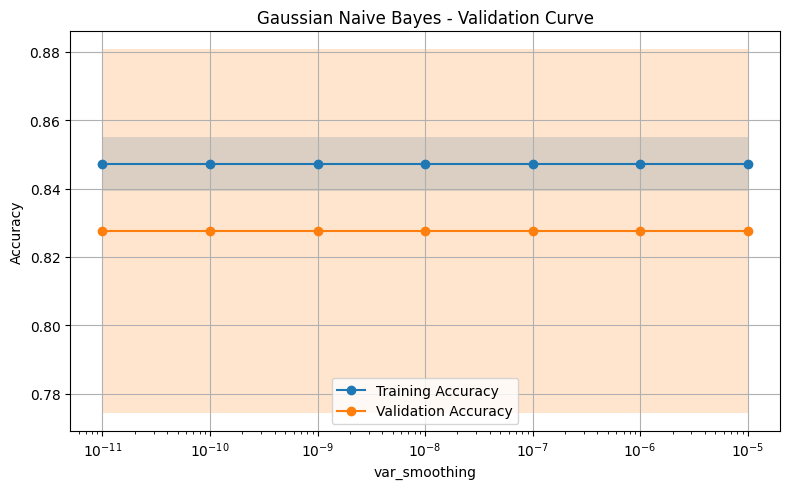

In [61]:
# Validation Curve

param_range = np.logspace(-11, -5, 7)

train_scores, test_scores = validation_curve(
    estimator=GaussianNB(),
    X=X_train,
    y=y_train,
    param_name="var_smoothing",
    param_range=param_range,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    param_range,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    param_range,
    test_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.fill_between(
    param_range,
    train_mean-train_std,
    train_mean+train_std,
    alpha=0.2
)

plt.fill_between(
    param_range,
    test_mean-test_std,
    test_mean+test_std,
    alpha=0.2
)

plt.xscale("log")

plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")
plt.title("Gaussian Naive Bayes - Validation Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

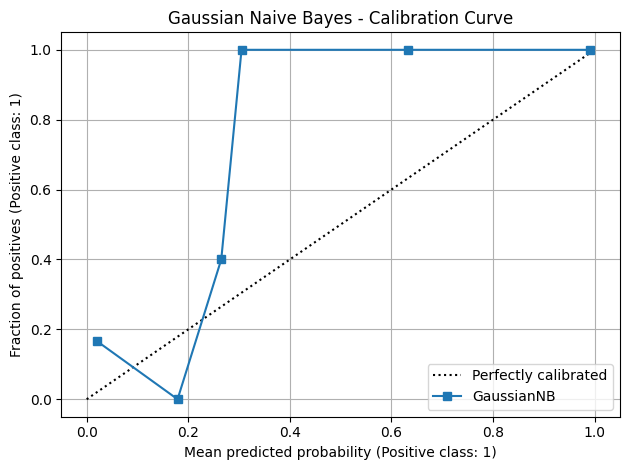

In [62]:
# Calibration Curve

CalibrationDisplay.from_estimator(
    gnb,
    X_test,
    y_test,
    n_bins=10
)

plt.title("Gaussian Naive Bayes - Calibration Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

In [63]:
# Save Results

gnb_results = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc,
    "Balanced_Accuracy": balanced_acc,
    "MCC": mcc,
    "Kappa": kappa,
    "Log_Loss": loss,
    "CV_Mean": cv_mean,
    "CV_STD": cv_std,
    "Train_Time": train_time,
    "Predict_Time": test_time
}

print(gnb_results)

{'Model': 'Gaussian Naive Bayes', 'Accuracy': 0.8666666666666667, 'Precision': 1.0, 'Recall': 0.7142857142857143, 'F1': 0.8333333333333334, 'ROC_AUC': np.float64(0.9129464285714285), 'Balanced_Accuracy': np.float64(0.8571428571428572), 'MCC': np.float64(0.7559289460184545), 'Kappa': np.float64(0.7272727272727273), 'Log_Loss': 0.43259137929193087, 'CV_Mean': np.float64(0.8275362318840578), 'CV_STD': np.float64(0.05311895714794872), 'Train_Time': 0.002480030059814453, 'Predict_Time': 0.002095937728881836}
